In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

mapa_cidades = {
    291360.0: 'Ilhéus', 291480.0: 'Itabuna', 
    '291360': 'Ilhéus', '291480': 'Itabuna',
    'Ilhéus': 'Ilhéus', 'Itabuna': 'Itabuna'
}

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Carrega o dicionário
try:
    with open('/home/bruno/UESC/DataSUS/DadosTUB/src/dicionario_sinan_tuberculose.json', 'r', encoding='utf-8') as f:
        dicionario = json.load(f)
except FileNotFoundError:
    print("Dicionário não encontrado.")

df = pd.read_csv('/home/bruno/UESC/DataSUS/DadosTUB/data/processed/tuberculose_ilheus_itabuna_final.csv')
colunas_data = [col for col in df.columns if 'Data' in col]
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")
df.head()

Dataset carregado: 3430 registros e 75 colunas.


,Tipo_Notificacao,Agravo_Codigo,Data_Notificacao,Ano_Notificacao,UF_Notificacao,Municipio_Notificacao,Regional_Notificacao,Data_Diagnostico,Ano_Nascimento,Sexo,...,Agravo_Tabagismo,Teste_Rapido_Molecular,Teste_Sensibilidade,Uso_Antiretroviral,Baciloscopia_Apos_6_Meses,Transferencia_Confirmada,UF_Transferencia,Municipio_Transferencia,Idade_Anos,Dias_Ate_Encerramento
0,2,A169,2015-12-04,2015,29,291360,1385,2015-12-03,1958.0,Feminino,...,2.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN,57,186.0
1,2,A169,2015-12-04,2015,29,291360,1385,2015-12-04,1945.0,Feminino,...,2.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,70,214.0
2,2,A169,2015-12-23,2015,29,291480,1386,2015-12-05,1981.0,Masculino,...,1.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,34,205.0
3,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1961.0,Masculino,...,1.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN,54,192.0
4,2,A169,2015-12-07,2015,29,291360,1385,2015-12-07,1985.0,Masculino,...,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,30,219.0


In [3]:
# Busca qualquer coluna relacionada à Unidade de Saúde ou CNES
colunas_cnes = [col for col in df.columns if 'unid' in col.lower() or 'cnes' in col.lower()]

print("Possíveis colunas de Unidade de Saúde encontradas:")
for col in colunas_cnes:
    print(f"- {col}")

Possíveis colunas de Unidade de Saúde encontradas:
- Tipo_Unidade_Notificacao


/tmp/ipykernel_50156/887396080.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem, y='Porta_de_Entrada', x='Percentual', palette='magma', ax=ax)
/tmp/ipykernel_50156/887396080.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem, y='Porta_de_Entrada', x='Percentual', palette='magma', ax=ax)


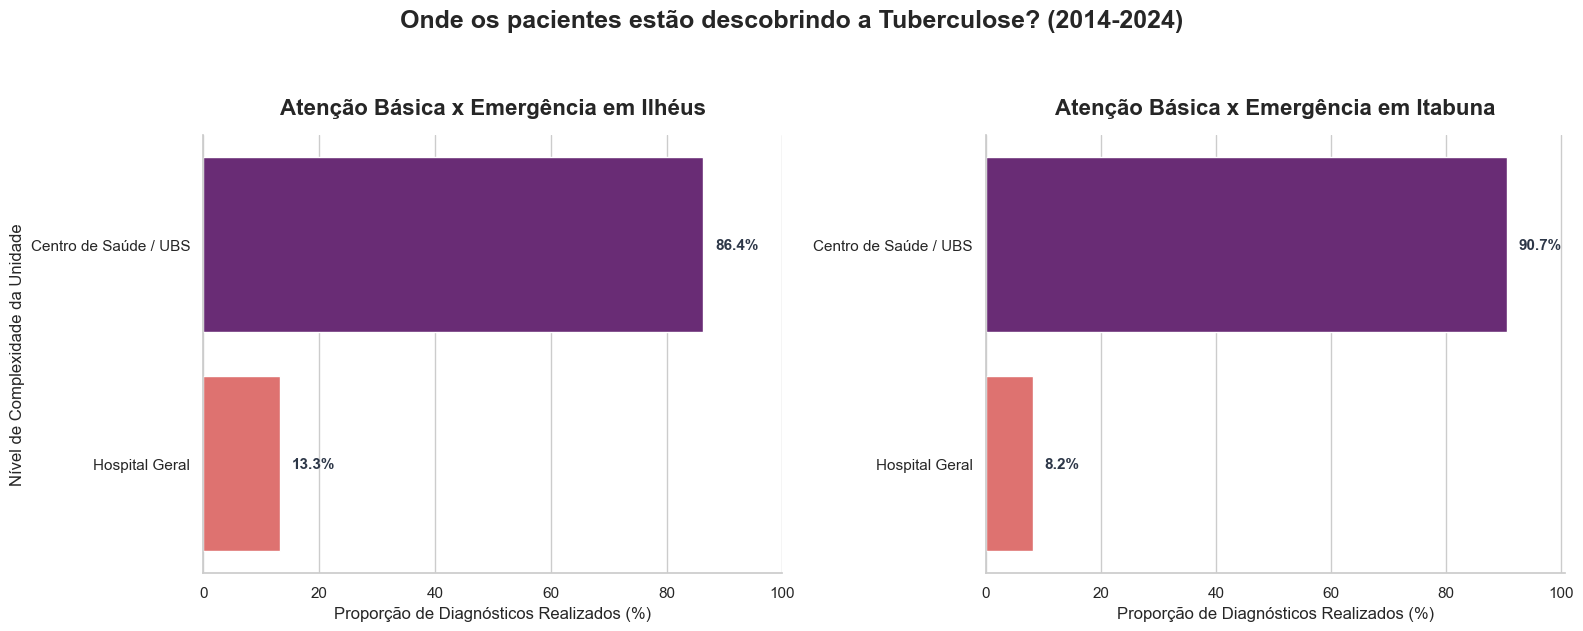

In [6]:
coluna_posto = 'Tipo_Unidade_Notificacao'

df_logistica = df.copy()

if 'Nome_Municipio' not in df_logistica.columns:
    df_logistica['Nome_Municipio'] = df_logistica['Municipio_Residencia'].map(mapa_cidades)
df_logistica = df_logistica[df_logistica['Nome_Municipio'].isin(['Ilhéus', 'Itabuna'])]

if coluna_posto not in df_logistica.columns:
    print(f"ERRO: A coluna '{coluna_posto}' não foi encontrada. Verifique se há acentos ou letras maiúsculas.")
else:
    df_logistica = df_logistica.dropna(subset=[coluna_posto])
    
    # Padroniza como string inteira (removendo o .0 do float, se houver)
    df_logistica[coluna_posto] = df_logistica[coluna_posto].astype(int).astype(str)

    # ==============================================================================
    # DICIONÁRIO DE TRADUÇÃO DO DATASUS (Ajuste conforme os códigos que aparecerem)
    # Se aparecer um código não listado aqui, basta adicionar a linha!
    mapa_tipo_unidade = {
        '1': 'Posto de Saúde (UBS)',
        '2': 'Centro de Saúde / UBS',
        '4': 'Policlínica',
        '5': 'Hospital Geral',
        '7': 'Hospital Especializado',
        '15': 'Unidade Mista',
        '36': 'Clínica Especializada',
        '73': 'Pronto Atendimento (UPA)'
    }
    # ==============================================================================

    # Aplica a tradução
    df_logistica['Porta_de_Entrada'] = df_logistica[coluna_posto].map(mapa_tipo_unidade).fillna('Código: ' + df_logistica[coluna_posto])

    # 2. PLOTAGEM DO DIAGNÓSTICO DO SISTEMA (LADO A LADO)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False) # ShareY=False para não esmagar gráficos pequenos
    cidades = ['Ilhéus', 'Itabuna']

    for i, cidade in enumerate(cidades):
        ax = axes[i]
        df_cidade = df_logistica[df_logistica['Nome_Municipio'] == cidade]
        
        # Agrupamento e proporção para evitar distorção populacional
        contagem = df_cidade['Porta_de_Entrada'].value_counts(normalize=True) * 100
        
        # Filtra para mostrar apenas os tipos de unidade que representam mais de 1% dos casos
        contagem = contagem[contagem > 1.0].reset_index()
        contagem.columns = ['Porta_de_Entrada', 'Percentual']
        
        sns.barplot(data=contagem, y='Porta_de_Entrada', x='Percentual', palette='magma', ax=ax)
        
        ax.set_title(f'Atenção Básica x Emergência em {cidade}', fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('Proporção de Diagnósticos Realizados (%)', fontsize=12)
        ax.set_ylabel('Nível de Complexidade da Unidade' if i == 0 else '', fontsize=12)
        ax.set_xlim(0, max(contagem['Percentual'].max() + 10, 100)) # Ajuste dinâmico de margem
        
        # Anotações nas barras
        for p in ax.patches:
            largura = p.get_width()
            ax.text(largura + 2, p.get_y() + p.get_height()/2, 
                    f'{largura:.1f}%', va='center', fontsize=11, fontweight='bold', color='#2d3748')

    plt.suptitle('Onde os pacientes estão descobrindo a Tuberculose? (2014-2024)', 
                 fontsize=18, fontweight='bold', y=1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [7]:
# Busca colunas que indiquem o local de notificação ou tratamento
opcoes_atendimento = [col for col in df.columns if 'notif' in col.lower() or 'trat' in col.lower()]
print("Colunas de atendimento encontradas:")
for col in opcoes_atendimento:
    print(f"- {col}")

Colunas de atendimento encontradas:
- Tipo_Notificacao
- Data_Notificacao
- Ano_Notificacao
- UF_Notificacao
- Municipio_Notificacao
- Regional_Notificacao
- Data_Inicio_Tratamento
- UF_Atual_Tratamento
- Municipio_Atual_Tratamento
- Data_Atualizacao_Notificacao
- Tratamento_Supervisionado_Atual
- Tipo_Unidade_Notificacao


/tmp/ipykernel_50156/3820758713.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#3182ce', '#dd6b20'], ax=ax)
/tmp/ipykernel_50156/3820758713.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#3182ce', '#dd6b20'], ax=ax)


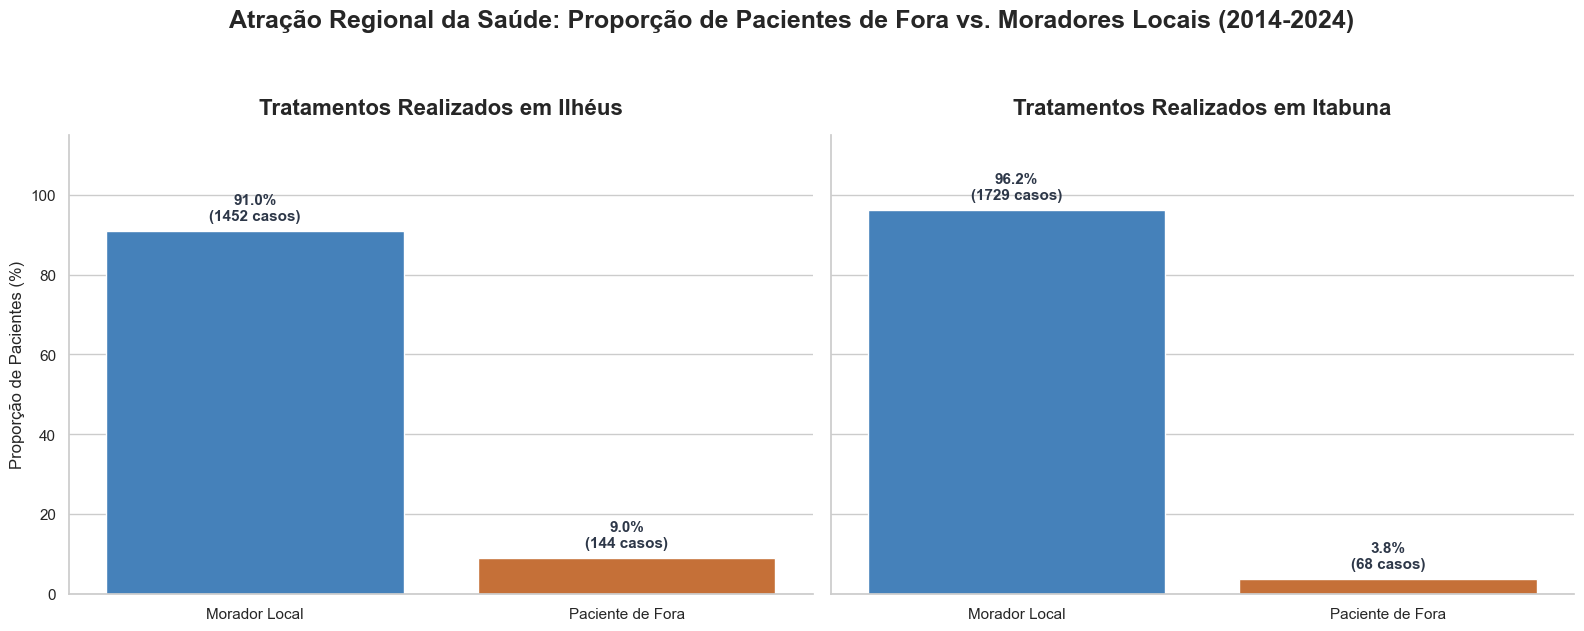

In [8]:
# 1. PREPARAÇÃO DOS DADOS DE FLUXO REGIONAL
df_fluxo = df.copy()

coluna_tratamento = 'Municipio_Atual_Tratamento'

# Mapear a cidade onde o tratamento está acontecendo
df_fluxo['Cidade_Tratamento'] = df_fluxo[coluna_tratamento].map(mapa_cidades)

# Filtrar apenas para os tratamentos que ocorrem de fato em Ilhéus ou Itabuna
df_fluxo = df_fluxo[df_fluxo['Cidade_Tratamento'].isin(['Ilhéus', 'Itabuna'])]

# Mapear a cidade onde o paciente mora
# Se morar em outra cidade (que não está no mapa de Ilhéus/Itabuna), vira 'Outro Município'
df_fluxo['Cidade_Residencia'] = df_fluxo['Municipio_Residencia'].map(mapa_cidades).fillna('Outro Município')

# Classificar a origem epidemiológica do paciente
df_fluxo['Origem_Paciente'] = df_fluxo.apply(
    lambda r: 'Morador Local' if r['Cidade_Tratamento'] == r['Cidade_Residencia'] else 'Paciente de Fora', 
    axis=1
)

# 2. PLOTAGEM DO GRÁFICO COMPARATIVO (LADO A LADO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_cidade = df_fluxo[df_fluxo['Cidade_Tratamento'] == cidade]
    
    # Cálculo das proporções internas de cada polo de tratamento
    contagem = df_cidade['Origem_Paciente'].value_counts(normalize=True) * 100
    df_plot = contagem.reset_index()
    df_plot.columns = ['Origem', 'Porcentagem (%)']
    
    # Garantir a ordem das barras para comparação visual direta
    df_plot = df_plot.set_index('Origem').reindex(['Morador Local', 'Paciente de Fora']).reset_index()
    
    sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#3182ce', '#dd6b20'], ax=ax)
    
    ax.set_title(f'Tratamentos Realizados em {cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Proporção de Pacientes (%)' if i == 0 else '', fontsize=12)
    ax.set_ylim(0, 115)
    
    # Adicionando os valores exatos e o número absoluto absoluto em cima das barras
    for p in ax.patches:
        altura = p.get_height()
        if not pd.isna(altura) and altura > 0:
            # Recuperar o total absoluto para colocar entre parênteses
            origem_tipo = 'Morador Local' if p.get_x() < 0.5 else 'Paciente de Fora'
            total_absoluto = df_cidade['Origem_Paciente'].value_counts().get(origem_tipo, 0)
            
            ax.text(p.get_x() + p.get_width()/2., altura + 2, 
                    f'{altura:.1f}%\n({total_absoluto} casos)', 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2d3748')

plt.suptitle('Atração Regional da Saúde: Proporção de Pacientes de Fora vs. Moradores Locais (2014-2024)', 
             fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

#### A análise do fluxo de atendimento revelou um perfil de absorção regional. Ao contrário da dinâmica comum da região, onde Itabuna centraliza a demanda por serviços de saúde gerais, no tratamento da Tuberculose o município demonstrou um perfil retido, com 96.2% dos atendimentos voltados aos próprios residentes. Em contrapartida, Ilhéus apresentou uma taxa de atração superior, absorvendo cerca de 9% de pacientes de outros municípios. Isso indica que a infraestrutura de saúde ilheense está atuando como suporte logístico para o tratamento de populações vizinhas ou turistas, o que demanda atenção no planejamento de repasses de recursos e medicamentos.

/tmp/ipykernel_50156/1543339641.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#38a169', '#d53f8c'], ax=ax)
/tmp/ipykernel_50156/1543339641.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#38a169', '#d53f8c'], ax=ax)


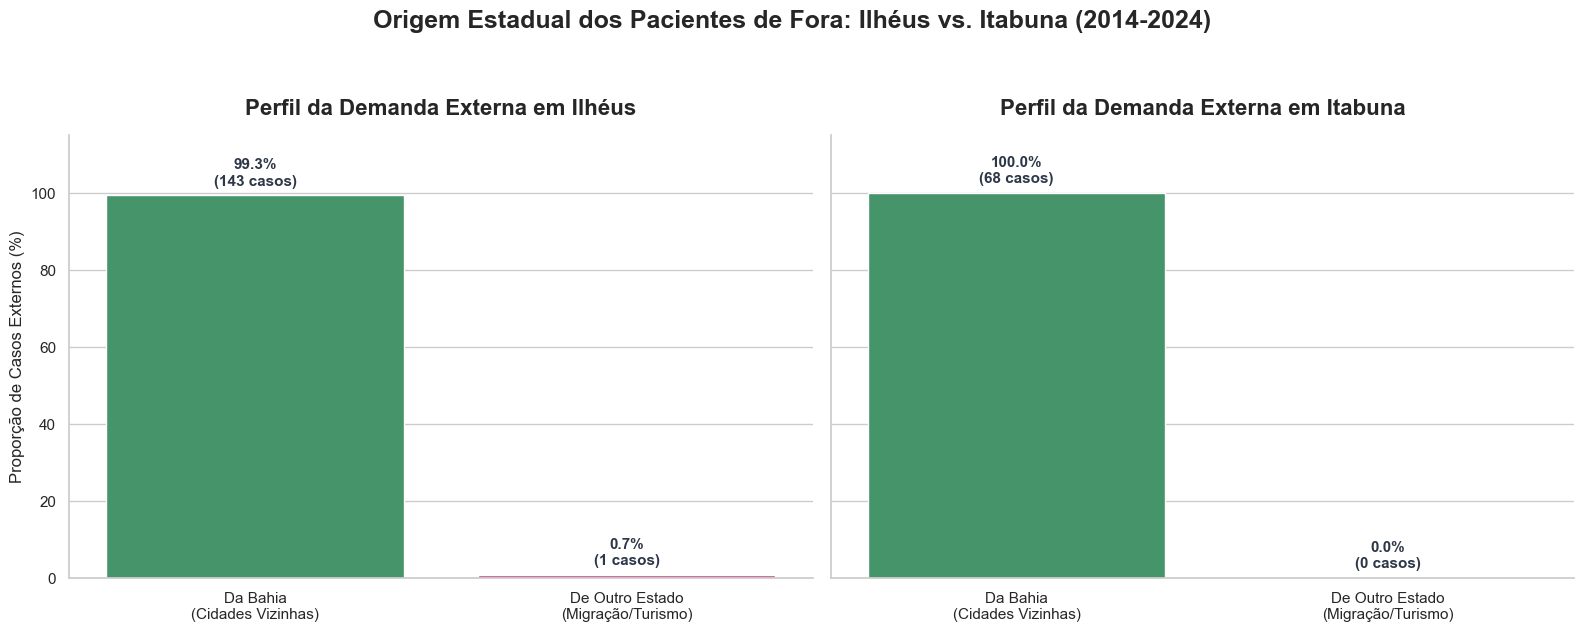

In [13]:
# 1. FILTRAR APENAS OS PACIENTES DE FORA
df_turismo = df_fluxo[df_fluxo['Origem_Paciente'] == 'Paciente de Fora'].copy()

# Pega os 2 primeiros dígitos do código IBGE (que representam o Estado)
df_turismo['Codigo_UF'] = df_turismo['Municipio_Residencia'].astype(str).str.replace('.0', '', regex=False).str[:2]

def classificar_estado(codigo):
    if codigo == '29': 
        return 'Da Bahia\n(Cidades Vizinhas)'
    elif codigo.lower() in ['na', 'ou', 'nan']: 
        return 'Não Informado'
    else: 
        return 'De Outro Estado\n(Migração/Turismo)'

df_turismo['Origem_Estado'] = df_turismo['Codigo_UF'].apply(classificar_estado)
df_turismo = df_turismo[df_turismo['Origem_Estado'] != 'Não Informado']

# 2. PLOTAGEM DO GRÁFICO COMPARATIVO LADO A LADO
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cidades = ['Ilhéus', 'Itabuna']

for i, cidade in enumerate(cidades):
    ax = axes[i]
    df_cidade = df_turismo[df_turismo['Cidade_Tratamento'] == cidade]
    
    if not df_cidade.empty:
        contagem = df_cidade['Origem_Estado'].value_counts(normalize=True) * 100
        df_plot = contagem.reset_index()
        df_plot.columns = ['Origem', 'Porcentagem (%)']
        
        # Garante a presença de ambas as categorias no eixo X para manter a simetria estrutural
        df_plot = df_plot.set_index('Origem').reindex([
            'Da Bahia\n(Cidades Vizinhas)', 
            'De Outro Estado\n(Migração/Turismo)'
        ]).fillna(0).reset_index()
        
        sns.barplot(data=df_plot, x='Origem', y='Porcentagem (%)', palette=['#38a169', '#d53f8c'], ax=ax)
        
        # Adicionar os rótulos de dados com percentual e total absoluto
        for index, row in df_plot.iterrows():
            altura = row['Porcentagem (%)']
            absoluto = df_cidade['Origem_Estado'].value_counts().get(row['Origem'], 0)
            ax.text(index, altura + 2, f'{altura:.1f}%\n({absoluto} casos)', 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2d3748')
            
    ax.set_title(f'Perfil da Demanda Externa em {cidade}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Proporção de Casos Externos (%)' if i == 0 else '')
    ax.set_ylim(0, 115)

plt.suptitle('Origem Estadual dos Pacientes de Fora: Ilhéus vs. Itabuna (2014-2024)', 
             fontsize=18, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

#### Isso prova que Ilhéus atua fortemente como uma "rede de segurança" para a atenção primária da micro-região.

Conectando à API do IBGE para baixar os nomes dos municípios...
Dicionário do IBGE carregado com sucesso!
Gerando o Top 15...


/tmp/ipykernel_50156/3747694925.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, y='Cidade_Origem', x='Total_Casos', palette='viridis', ax=ax)
/tmp/ipykernel_50156/3747694925.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, y='Cidade_Origem', x='Total_Casos', palette='viridis', ax=ax)


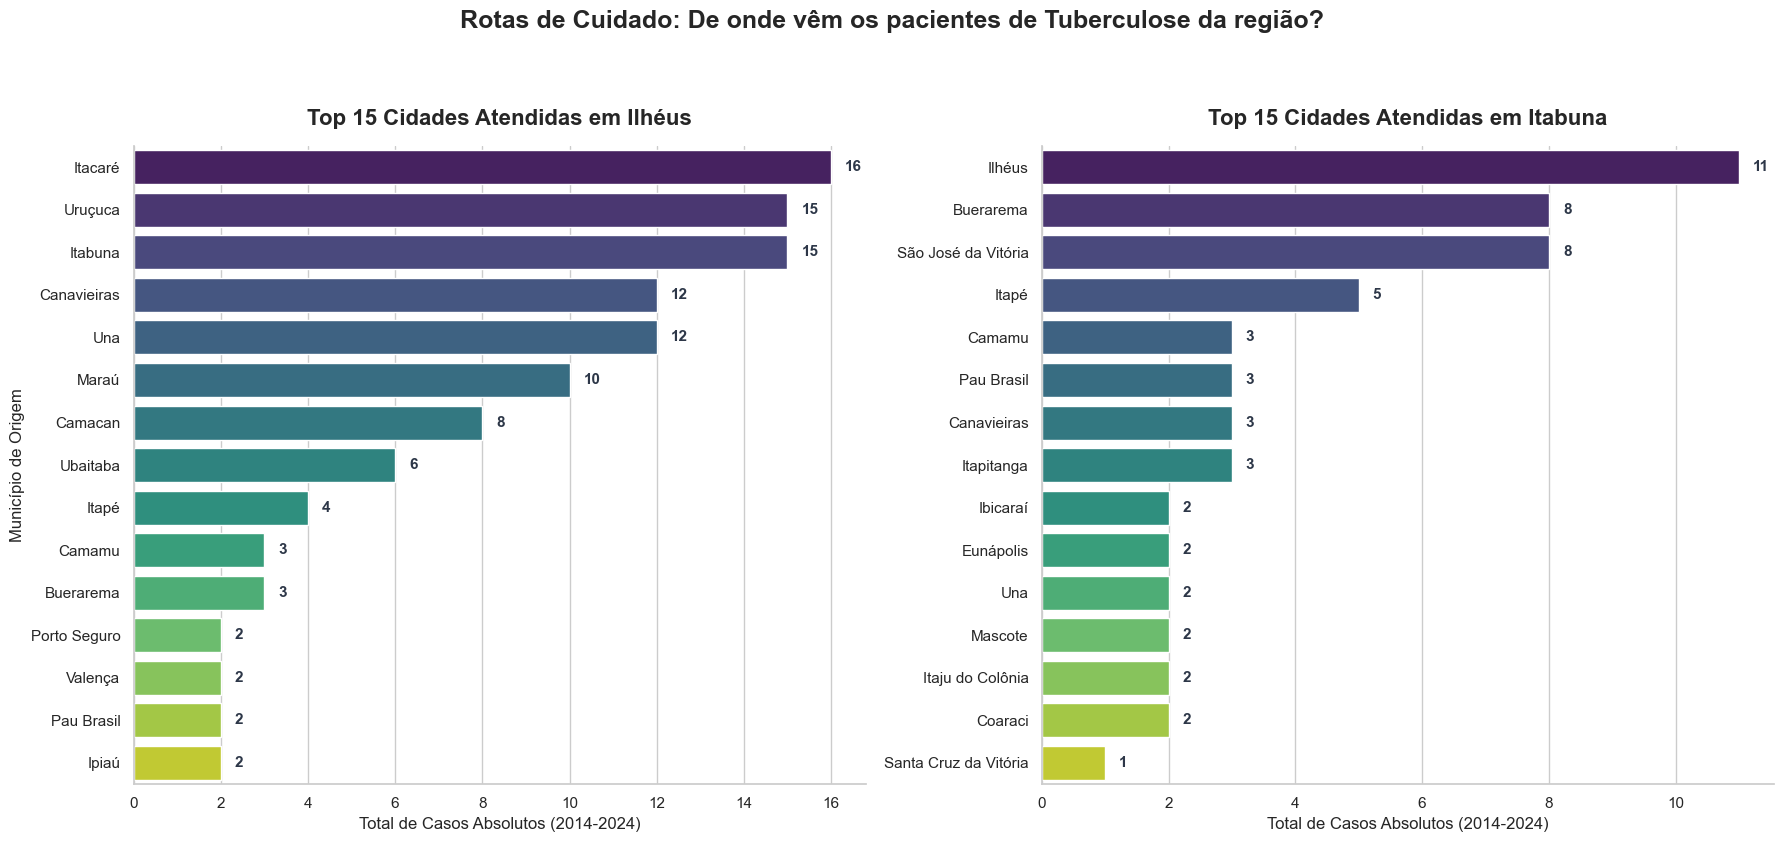

In [15]:
import requests

# 1. CONSUMO DA API DO IBGE E MAPEAMENTO
print("Conectando à API do IBGE para baixar os nomes dos municípios...")
url_ibge = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
resposta = requests.get(url_ibge)

if resposta.status_code == 200:
    dados_ibge = resposta.json()
    # O SINAN usa códigos de 6 dígitos (ignora o 7º dígito verificador do IBGE)
    mapa_ibge = {str(mun['id'])[:6]: mun['nome'] for mun in dados_ibge}
    print("Dicionário do IBGE carregado com sucesso!\nGerando o Top 15...")
    
    # Extrai o código de 6 dígitos da sua base de pacientes de fora
    df_turismo['Codigo_6_digitos'] = df_turismo['Municipio_Residencia'].astype(str).str.replace('.0', '', regex=False).str[:6]
    
    # Faz a tradução mágica
    df_turismo['Nome_Cidade_Origem'] = df_turismo['Codigo_6_digitos'].map(mapa_ibge).fillna('Código Desconhecido')
    
    # 2. PLOTAGEM DO TOP 15 LADO A LADO
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)
    cidades = ['Ilhéus', 'Itabuna']

    for i, cidade in enumerate(cidades):
        ax = axes[i]
        df_cidade = df_turismo[df_turismo['Cidade_Tratamento'] == cidade]
        
        # Pega as 15 cidades que mais mandam pacientes
        top_15 = df_cidade['Nome_Cidade_Origem'].value_counts().head(15).reset_index()
        top_15.columns = ['Cidade_Origem', 'Total_Casos']
        
        sns.barplot(data=top_15, y='Cidade_Origem', x='Total_Casos', palette='viridis', ax=ax)
        
        ax.set_title(f'Top 15 Cidades Atendidas em {cidade}', fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('Total de Casos Absolutos (2014-2024)', fontsize=12)
        ax.set_ylabel('Município de Origem' if i == 0 else '', fontsize=12)
        
        # Adiciona os números exatos nas barras para facilitar a leitura
        for p in ax.patches:
            largura = p.get_width()
            if largura > 0:
                ax.text(largura + (top_15['Total_Casos'].max() * 0.02), p.get_y() + p.get_height()/2, 
                        f'{int(largura)}', va='center', fontsize=11, fontweight='bold', color='#2d3748')

    plt.suptitle('Rotas de Cuidado: De onde vêm os pacientes de Tuberculose da região?', 
                 fontsize=18, fontweight='bold', y=1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

else:
    print("Falha ao conectar com o IBGE. Verifique sua conexão com a internet.")